In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package')

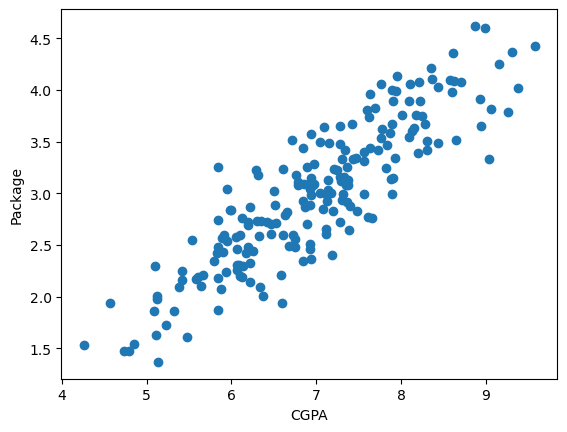

In [3]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package')

In [4]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [5]:
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
X_train

,cgpa
79,7.18
197,7.21
38,8.62
24,6.53
122,5.12
...,...
106,6.13
14,7.73
92,7.90
179,7.14


In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

Text(0, 0.5, 'Package')

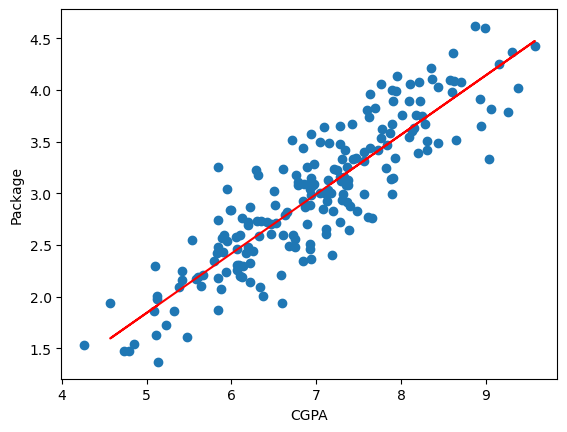

In [8]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color = 'red')
plt.xlabel("CGPA")
plt.ylabel("Package")

In [9]:
y_pred = lr.predict(X_test)

## Mean Squared Error
#### Average of the squared differences between actual and predicted values (lower is better)

In [10]:
print("MSE", mean_squared_error(y_pred, y_test))

MSE 0.08417638361329657


## Mean Absolute Error
#### Average of absolute differences between actual and predicted values (lower = better)

In [11]:
print("MAE", mean_absolute_error(y_pred, y_test))

MAE 0.23150985393278373


## RMSE
#### Square root of MSE, Average of absolute differences between actual and predicted values (lower = better)

In [12]:
print("RMSE", root_mean_squared_error(y_pred, y_test))

RMSE 0.2901316659954521


In [13]:
print("RMSE", np.sqrt(mean_squared_error(y_pred, y_test)))

RMSE 0.2901316659954521


## R2 Score
#### Proportion of variance in the dependent variable explained by the model (closer to 1 is better)

In [14]:
print("R2 Score", r2_score(y_pred, y_test))

R2 Score 0.733797338294438


## Adjusted R2 Score
#### Modified R² that adjusts for the number of predictors, penalizing unnecessary features.

In [15]:
r2 = r2_score(y_pred, y_test)

In [16]:
X_test.shape

(40, 1)

In [17]:
adjusted_r2 = 1 - ((1-r2) * (40-1) / (40-1-1))

In [18]:
adjusted_r2

0.7267920050916601

## Implementation all the things again but here we add one feature

In [19]:
new_df = df.copy()
new_df['random_feature'] = np.random.random(200)

new_df = new_df[['cgpa', 'random_feature', 'package']]
new_df.head()

,cgpa,random_feature,package
0,6.89,0.308523,3.26
1,5.12,0.813923,1.98
2,7.82,0.715697,3.25
3,7.42,0.035647,3.67
4,6.94,0.649228,3.57


Text(0, 0.5, 'Package (in LPA)')

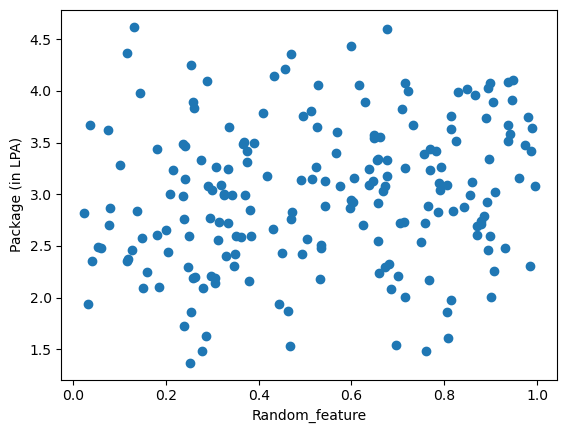

In [20]:
plt.scatter(new_df['random_feature'], new_df['package'])
plt.xlabel('Random_feature')
plt.ylabel('Package (in LPA)')

In [21]:
X = new_df.iloc[:, 0:2]
y = new_df.iloc[:,-1]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
X_train

,cgpa,random_feature
79,7.18,0.324407
197,7.21,0.637084
38,8.62,0.469659
24,6.53,0.878690
122,5.12,0.714551
...,...,...
106,6.13,0.257458
14,7.73,0.375317
92,7.90,0.721405
179,7.14,0.669008


In [24]:
lr1 = LinearRegression()

lr1.fit(X_train, y_train)

LinearRegression()

In [25]:
y_pred = lr1.predict(X_test)

## R2 score

In [26]:
print("R2 Score", r2_score(y_pred, y_test))

R2 Score 0.7435986858482597


In [27]:
r2 = r2_score(y_pred, y_test)

## Adjusted R2 score

In [28]:
X_test.shape

(40, 2)

In [41]:
adjusted_r2_score = 1 - ((1 - r2) * (40-1) / (40-1-2))

In [42]:
adjusted_r2_score

0.7425216520471207

## Adding New feature

In [31]:
new_df2 = df.copy()
new_df2['iq'] = new_df2['package'] + (np.random.randint(-12 , 12, 200) / 10)

new_df2 = new_df2[['cgpa', 'iq', 'package']]

new_df2.sample(5)

,cgpa,iq,package
193,4.57,0.84,1.94
30,7.36,2.66,3.26
195,6.93,2.96,2.46
123,5.10,2.50,2.30
144,6.17,2.52,2.42


Text(0, 0.5, 'Package')

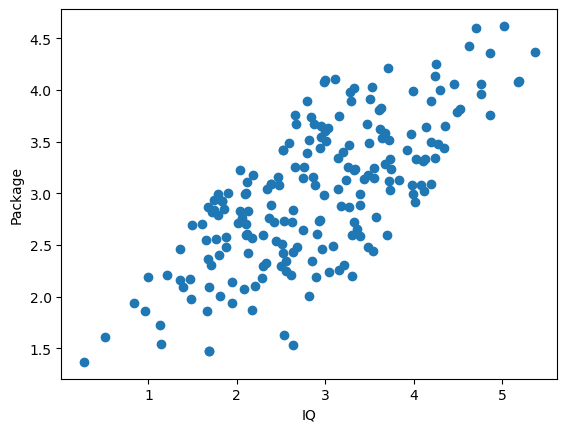

In [32]:
plt.scatter(new_df2['iq'], new_df2['package'])
plt.xlabel('IQ')
plt.ylabel('Package')

In [33]:
X = new_df2.iloc[:, 0:2]
y = new_df2.iloc[:, -1]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
X_train.sample(5)

,cgpa,iq
51,9.26,4.49
179,7.14,3.73
144,6.17,2.52
50,9.58,4.63
14,7.73,3.92


In [36]:
lr2 = LinearRegression()

lr2.fit(X_train, y_train)

LinearRegression()

In [37]:
y_pred = lr2.predict(X_test)

## R2 Score

In [43]:
print("R2 Score", r2_score(y_pred, y_test))

R2 Score 0.7557256698908581


In [44]:
r2 = r2_score(y_pred, y_test)

## Adjusted R2 score

In [45]:
1 - ((1-r2) * (40-1) / (40-1-2))

0.7425216520471207